# Controllable generation by imputation

In this section we implement image imputation with the Ornstein-Uhlenbeck (OU) diffusion model, the cosine noise schedule, and the Euler-Maruyama reverse-time sampler.

The goal is to reconstruct missing pixels from partially observed MNIST images. The known pixels are enforced during reverse diffusion through a binary mask.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys
from pathlib import Path

# Ruta raíz del proyecto en Drive
PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models")

# Carpetas principales
NOTEBOOKS_DIR = PROJECT_PATH / "notebooks"
SRC_DIR = PROJECT_PATH / "src"
CHECKPOINTS_DIR = PROJECT_PATH / "checkpoints"
RESULTS_DIR = PROJECT_PATH / "results"

# Añadir src al path para poder importar los .py
sys.path.insert(0, str(SRC_DIR))

# Crear carpetas si no existen
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_PATH =", PROJECT_PATH)
print("SRC_DIR =", SRC_DIR)
print("CHECKPOINTS_DIR =", CHECKPOINTS_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_PATH = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
SRC_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src
CHECKPOINTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints
RESULTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/results


In [3]:

import numpy as np
from functools import partial

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor

import diffusion_process as dfp

from score_model import ScoreNet
from diffusion_utilities import plot_image_grid, plot_image_evolution

from conditional_sampling import (
    make_right_half_mask,
    make_center_square_mask,
    apply_mask,
    cosine_alpha_bar,
    cosine_beta_t,
    ou_cosine_drift_coefficient,
    ou_cosine_diffusion_coefficient,
    ou_cosine_mu_t,
    ou_cosine_sigma_t,
    impute_ou_euler_maruyama,
)

In [4]:
# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Number of threads
n_threads = torch.get_num_threads()
print("Number of threads:", n_threads)

# Reproducibility
torch.manual_seed(123)
np.random.seed(123)

Device: cuda
Number of threads: 1


## OU cosine diffusion model

We use the OU forward diffusion process:
$$
d\mathbf{x}(t) = -\frac{1}{2}\beta(t)\mathbf{x}(t)\,dt + \sqrt{\beta(t)}\,d\mathbf{W}(t),
$$
with the cosine schedule $\beta(t)$.

For this model:
$$
\mu_t(\mathbf{x}_0) = \sqrt{\bar{\alpha}(t)}\,\mathbf{x}_0,
\qquad
\sigma_t = \sqrt{1-\bar{\alpha}(t)}.
$$

The trained score network approximates the score function
$\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$,
and the reverse SDE is integrated from $T$ to a small positive value using Euler-Maruyama.

In [5]:
drift_coefficient = ou_cosine_drift_coefficient
diffusion_coefficient = ou_cosine_diffusion_coefficient
mu_t = ou_cosine_mu_t
sigma_t = ou_cosine_sigma_t

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

In [6]:
score_model = torch.nn.DataParallel(
    ScoreNet(
        marginal_prob_std=sigma_t
    )
)
score_model = score_model.to(device)

In [7]:
checkpoint_path = CHECKPOINTS_DIR / "ou_mnist_all_digits_cosine.pth"
print("Checkpoint path:", checkpoint_path)

checkpoint = torch.load(checkpoint_path, map_location=device)
score_model.load_state_dict(checkpoint)
score_model.eval()

print("Checkpoint loaded correctly from:", checkpoint_path)

Checkpoint path: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_all_digits_cosine.pth
Checkpoint loaded correctly from: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_all_digits_cosine.pth


In [8]:
data = datasets.MNIST(
    root=PROJECT_PATH / "data",
    train=True,
    download=True,
    transform=ToTensor(),
)

print(type(data))
print("Number of training images:", len(data))

<class 'torchvision.datasets.mnist.MNIST'>
Number of training images: 60000


In [9]:
n_images = 6

indices = torch.arange(n_images)
subset = Subset(data, indices)

images_0 = torch.stack([subset[i][0] for i in range(n_images)], dim=0).to(device)
labels = torch.tensor([subset[i][1] for i in range(n_images)], device=device)

print("images_0 shape:", images_0.shape)
print("labels:", labels.cpu().numpy())

images_0 shape: torch.Size([6, 1, 28, 28])
labels: [5 0 4 1 9 2]


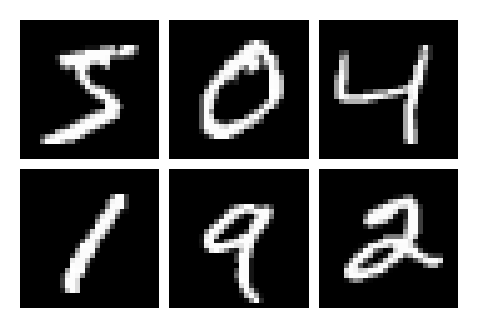

In [10]:
_ = plot_image_grid(
    images=[images_0[i].cpu() for i in range(n_images)],
    figsize=(6, 4),
    n_rows=2,
    n_cols=3,
)

In [11]:
mask = make_right_half_mask(images_0)
images_masked = apply_mask(images_0, mask, fill_value=0.0)

print("mask shape:", mask.shape)

mask shape: torch.Size([6, 1, 28, 28])


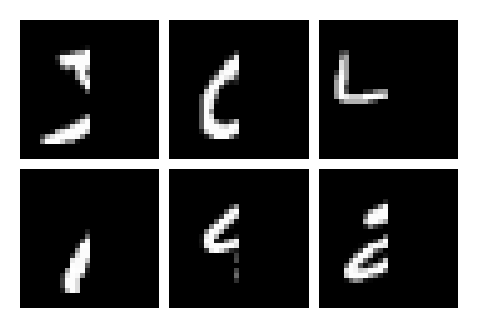

In [12]:
_ = plot_image_grid(
    images=[images_masked[i].cpu() for i in range(n_images)],
    figsize=(6, 4),
    n_rows=2,
    n_cols=3,
)

## Reverse-time imputation with Euler-Maruyama

We start from a Gaussian sample at time $T$, then we integrate the reverse SDE from $T$ to a small value $\varepsilon$.

At each reverse step, we re-impose the observed region through the mask:
$$
\mathbf{x}_t \leftarrow \mathbf{M}\odot \mathbf{x}^{obs}_t + (1-\mathbf{M})\odot \mathbf{x}_t,
$$
where $\mathbf{x}^{obs}_t$ is the noisy version of the observed image at time $t$.

In [13]:
T = 0.95
eps = 1.0e-4
n_steps = 1500

with torch.no_grad():
    times, imputed_images_t = impute_ou_euler_maruyama(
        x_observed=images_0,
        mask=mask,
        score_model=score_model,
        drift_coefficient_fn=drift_coefficient,
        diffusion_coefficient_fn=diffusion_coefficient,
        mu_t_fn=mu_t,
        sigma_t_fn=sigma_t,
        T=T,
        eps=eps,
        n_steps=n_steps,
    )

print("times shape:", times.shape)
print("imputed_images_t shape:", imputed_images_t.shape)

times shape: torch.Size([1501])
imputed_images_t shape: torch.Size([6, 1, 28, 28, 1501])


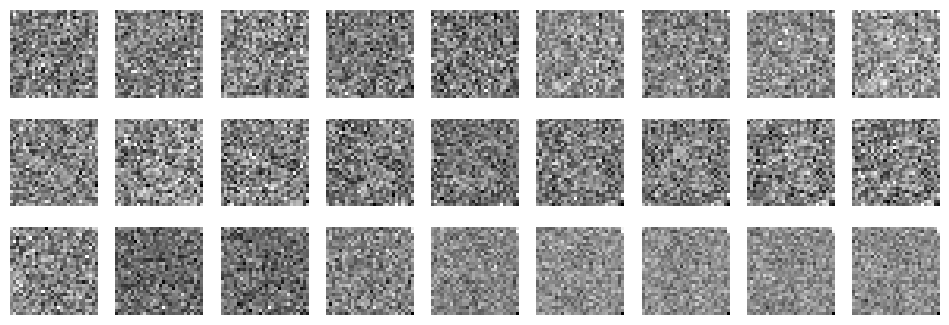

In [14]:
_ = plot_image_evolution(
    images=imputed_images_t.cpu(),
    n_images=3,
    n_intermediate_steps=[0, 50, 100, 200, 300, 400, 450, 499, 500],
    figsize=(12, 4),
)

In [15]:
images_imputed_final = imputed_images_t[..., -1]
images_imputed_final = torch.clamp(images_imputed_final, 0.0, 1.0)

images_imputed_final = torch.where(
    images_imputed_final < 0.15,
    torch.zeros_like(images_imputed_final),
    images_imputed_final
)
print("images_imputed_final shape:", images_imputed_final.shape)

images_imputed_final shape: torch.Size([6, 1, 28, 28])


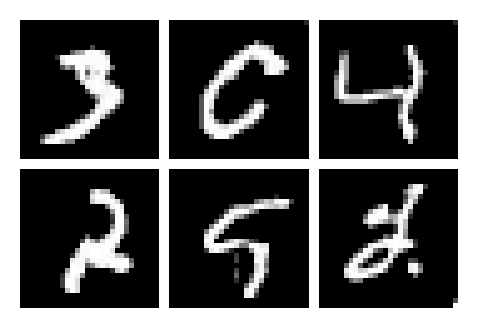

In [16]:
_ = plot_image_grid(
    images=[images_imputed_final[i].cpu() for i in range(n_images)],
    figsize=(6, 4),
    n_rows=2,
    n_cols=3,
)

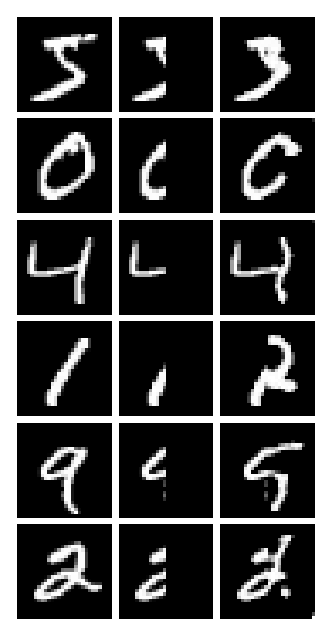

In [17]:
comparison_images = []

for i in range(n_images):
    comparison_images.append(images_0[i].cpu())
    comparison_images.append(images_masked[i].cpu())
    comparison_images.append(images_imputed_final[i].cpu())

_ = plot_image_grid(
    images=comparison_images,
    figsize=(9, 8),
    n_rows=n_images,
    n_cols=3,
)

### Segundo caso de uso: máscara cuadrada central

In [18]:
mask_center = make_center_square_mask(images_0, square_size=10)
images_masked_center = apply_mask(images_0, mask_center, fill_value=0.0)

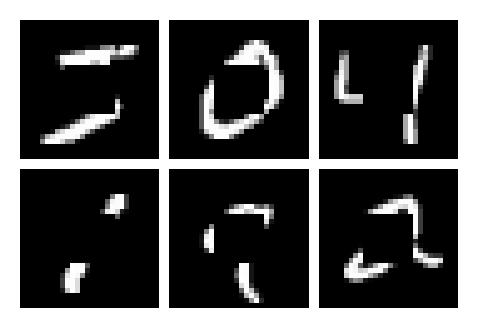

In [19]:
_ = plot_image_grid(
    images=[images_masked_center[i].cpu() for i in range(n_images)],
    figsize=(6, 4),
    n_rows=2,
    n_cols=3,
)

In [20]:
with torch.no_grad():
    times_center, imputed_images_t_center = impute_ou_euler_maruyama(
        x_observed=images_0,
        mask=mask_center,
        score_model=score_model,
        drift_coefficient_fn=drift_coefficient,
        diffusion_coefficient_fn=diffusion_coefficient,
        mu_t_fn=mu_t,
        sigma_t_fn=sigma_t,
        T=T,
        eps=eps,
        n_steps=n_steps,
    )

images_imputed_final_center = imputed_images_t_center[..., -1]

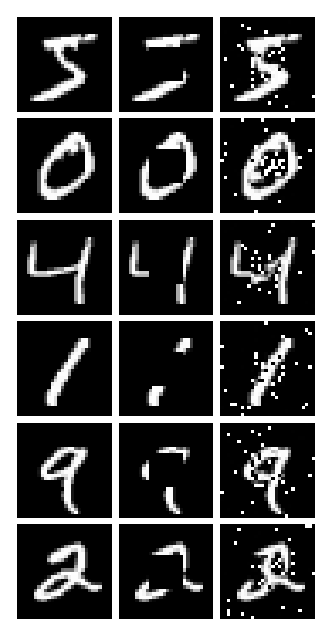

In [21]:
comparison_images_center = []

for i in range(n_images):
    comparison_images_center.append(images_0[i].cpu())
    comparison_images_center.append(images_masked_center[i].cpu())
    comparison_images_center.append(images_imputed_final_center[i].cpu())

_ = plot_image_grid(
    images=comparison_images_center,
    figsize=(9, 8),
    n_rows=n_images,
    n_cols=3,
)

### Imputation as controllable generation

Imputation can be formulated as a controllable generation task. Instead of generating a sample completely from noise, we constrain part of the image to remain compatible with the observed pixels.

At each reverse-time step, the known region is replaced by a noisy version of the observation at the same diffusion time, while the unknown region is updated by the reverse SDE. This allows the diffusion model to reconstruct the missing part consistently with the visible content.